In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
# --! import Python libraries and KIND framework files -------------------!

import torch
import numpy as np

from scipy import signal as sig
from matplotlib import pyplot as plt

import utils_data
import utils_detuning

## Data acquisition through simulation

inf >> half-bandwidth of this radio frequency cavity is 14.44 Herz
inf >> cavity filling time is 0.07 seconds
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 3


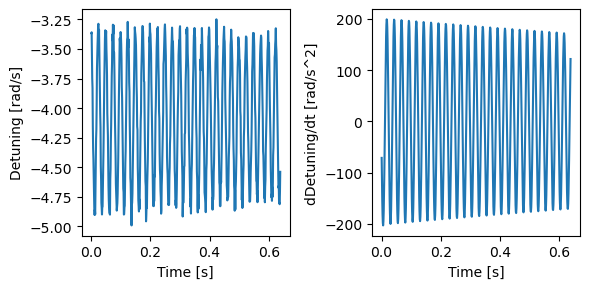

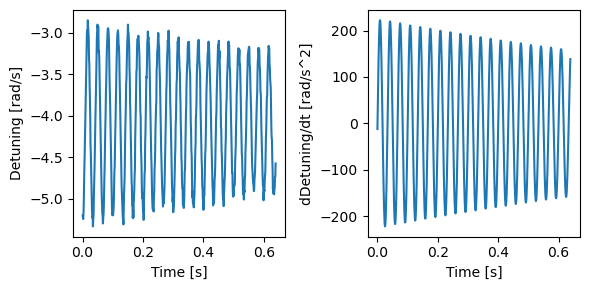

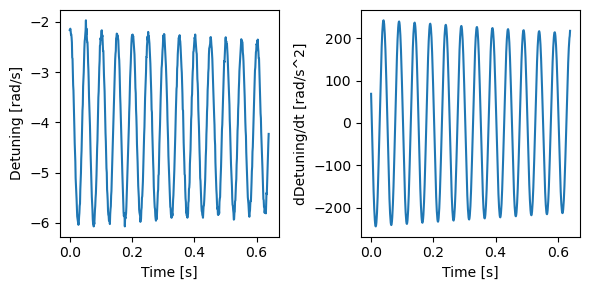

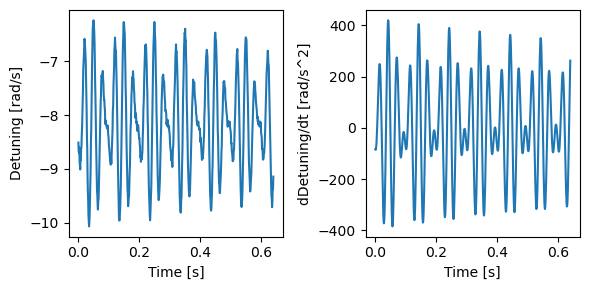

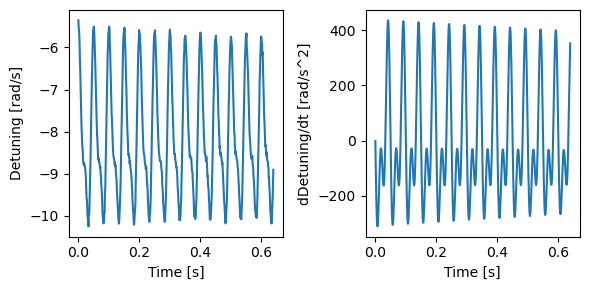

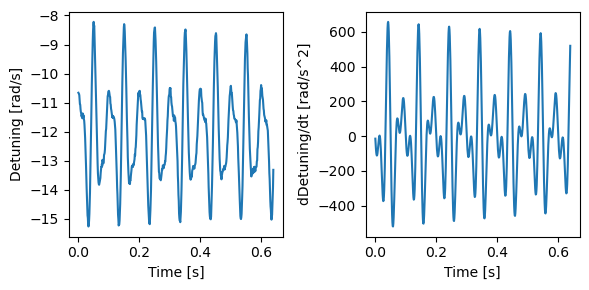

inf >> detuning shape is finally (640, 1)


In [3]:
# --! simulate detuning using a cavity simulator --!

# --! instatiate a cavity simulator
config = {
    'q_rf'       : 4.5e7,      # loaded quality factor
    'f_rf'       : 1.3e9,      # cavity frequency in hertz
    'v_rf'       : [5., 0.],   # generator voltage
    'pctr_on_rf' : False,      # prortional controller is on
    'K_rf'       : 100.        # proportional controller gain
}
sim = utils_detuning.detuning_sim(config)

dt = 0.001 # discretization step
ns = 0.05 # rms noise level

# --! define a list of simulation parameters
sim_param = [
    {
        'f_m'    : np.array([40.]),
        'fe_m'   : np.array([0.]),
        'q_m'    : np.array([400.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([30.]),
        'fe_m'   : np.array([0.]),
        'q_m'    : np.array([150.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([20.]),
        'fe_m'   : np.array([0.]),
        'q_m'    : np.array([200.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([40., 30.]),
        'fe_m'   : np.array([0., 0.]),
        'q_m'    : np.array([400., 150.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([40., 20.]),
        'fe_m'   : np.array([0., 0.]),
        'q_m'    : np.array([400., 200.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([40., 30., 20.]),
        'fe_m'   : np.array([0., 0., 0.]),
        'q_m'    : np.array([400., 150., 200.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
]

# --! simulate
detuning_sim_stat = sim(sim_param, start=60, noise=ns)

# --! display detuning results
for d in detuning_sim_stat:
    sim.disp(d, timestep=dt)

# --! but dump velocity state, as we do not need it now
for j in range(len(detuning_sim_stat)):
    detuning_sim_stat[j] = detuning_sim_stat[j][:, :1]
print(f'inf >> detuning shape is finally {detuning_sim_stat[0].shape}')

detuning_sim_nsample = detuning_sim_stat[0].shape[0]

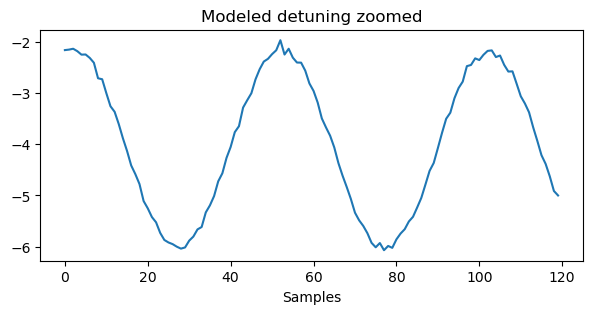

In [4]:
# --! inspect individual modeled detuning --!

plt.figure(figsize=(7, 3))
plt.title('Modeled detuning zoomed')
plt.plot(detuning_sim_stat[2][:120, 0])
plt.xlabel('Samples')
plt.show()

## Data acquisition from measurements

In [5]:
# --! helping functions for data readout --!

def convert(s):
    # The function that converts the string to float
      s = s.replace(',', '.')
      return float(s)

def read_detuning(name: str, nrow_skip: int=0, delim: str=None):
    return torch.tensor(
        np.loadtxt(
            name,
            delimiter=delim,
            skiprows=nrow_skip,
            dtype=np.float32,
            ndmin=2,
            converters=convert))

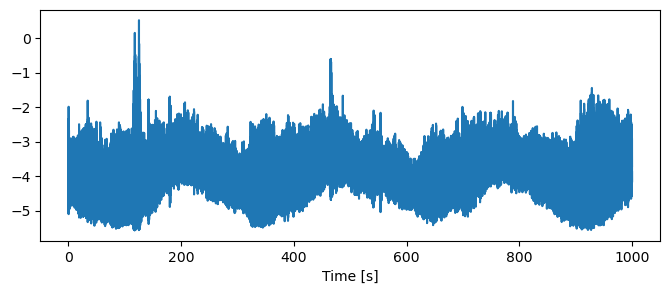

In [6]:
# --! read measured detuning data

dataname = '../../data/baselines/detuning_17072025_15-10_1_QL_4_5e7_KI_0x10000'
rawdata  = read_detuning(dataname, nrow_skip=23, delim='\t').numpy()

# --! show measured data
plt.figure(figsize=(8, 3))
plt.plot(rawdata[:, 0], rawdata[:, 1])
plt.xlabel('Time [s]')
plt.show()

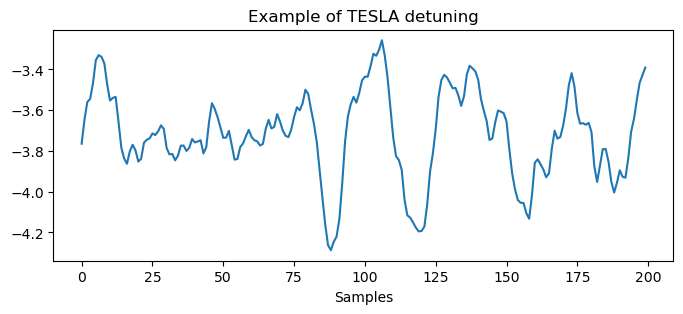

In [7]:
# --! stationary snippets --!

pos               = 900_000
nsample           = detuning_sim_nsample
detuning_stat1    = rawdata[pos:pos+nsample, [1]]

pos               = 99_800
nsample           = detuning_sim_nsample
detuning_stat2    = rawdata[pos:pos+nsample, [1]]

pos               = 50_200
nsample           = detuning_sim_nsample
detuning_stat3    = rawdata[pos:pos+nsample, [1]]

pos               = 120_000
nsample           = detuning_sim_nsample
detuning_stat4    = rawdata[pos:pos+nsample, [1]]

pos               = 150_000
nsample           = detuning_sim_nsample
detuning_stat5    = rawdata[pos:pos+nsample, [1]]

pos               = 109_000
nsample           = detuning_sim_nsample
detuning_stat6    = rawdata[pos:pos+nsample, [1]]

# --! transient snippets --!

pos               = 804_000
nsample           = detuning_sim_nsample
detuning_trans1   = rawdata[pos:pos+nsample, [1]]

pos               = 170_400
nsample           = detuning_sim_nsample
detuning_trans2   = rawdata[pos:pos+nsample, [1]]

pos               = 220_800
nsample           = detuning_sim_nsample
detuning_trans3   = rawdata[pos:pos+nsample, [1]]

pos               = 760_000
nsample           = detuning_sim_nsample
detuning_trans4   = rawdata[pos:pos+nsample, [1]]

# --! exemplify a snippet
pos               = 804_075
nsample           = 200
rawdata_v         = rawdata[pos:pos+nsample, 1]
plt.figure(figsize=(8, 3))
plt.title('Example of TESLA detuning')
plt.plot(rawdata_v)
plt.xlabel('Samples')
plt.show()

## Data saving for model development

In [8]:
# --! assemble stationary, transient and mixed datasets --!

detuning_sim_stat = detuning_sim_stat + [detuning_stat6]

detuning_trans = [
    detuning_trans1,
    detuning_trans2,
    detuning_trans3,
    detuning_trans4
]

detuning_mixed = detuning_sim_stat + detuning_trans

In [9]:
# --! save the stationary, transient and mixed datasets for training

datasaved = True

if datasaved:
    data_dir     = '../../data/baselines/train_tesla_stat'
    data_nsample = 120
    utils_data.save_traindata(detuning_sim_stat, data_dir, data_nsample)

if datasaved:
    data_dir     = '../../data/baselines/train_tesla_trans'
    data_nsample = 120
    utils_data.save_traindata(detuning_trans, data_dir, data_nsample)

if datasaved:
    data_dir     = '../../data/baselines/train_tesla_mixed'
    data_nsample = 120
    utils_data.save_traindata(detuning_mixed, data_dir, data_nsample)

inf >> training files saved
inf >> training files saved
inf >> training files saved


In [10]:
# --! save test dataset
pos               = 804_075#109_000
nsample           = detuning_sim_nsample
detuning_test     = rawdata[pos:pos+nsample, [1]]

datasaved = True
if datasaved:
    data_dir     = '../../data/baselines/test_tesla'
    data_nsample = 120
    utils_data.save_testdata([detuning_test], data_dir, data_nsample)

inf >> evaluation file saved
